# 02 Modelling: baseline, Ridge, LightGBM

**Goal:** explain log(market value) from performance, age, team and league, trained on **2024/25** and tested on
**2025/26** (temporal validation, no random split). This notebook walks through `src/train_models.py` step by step;
both use the same functions, so the numbers match. The script is the reproducible pipeline that writes the outputs
(`predictions.parquet`, `model_metrics.csv`, models); this notebook explains and visualises.

**Metrics**
- **R²** (log scale): share of the variance in log(value) the model explains. 1 = perfect, 0 = no better than the mean.
- **RMSE** (log scale): typical error in log units. 0.45 means a typical factor of about exp(0.45) = 1.57.
- **MdAPE** (EUR): median absolute percentage error. 0.29 = for the median player the prediction is 29% off.

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

# joblib counts CPU cores via `wmic`, which Windows 11 no longer ships (noisy warning).
# Setting a limit below the logical core count skips that lookup.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) - 1)))

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_predict

from src import config
from src.train_models import CV, GroupMedianBaseline, evaluate, load_data, make_ridge, tune_lgbm

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
POSITION_COLORS = {"Attack": "#2a78d6", "Midfield": "#1baf7a", "Defender": "#eb6a2a"}
BASE_COLOR = "#2a78d6"

def save(fig, name):
    """Save a figure to reports/figures for later use in the README."""
    config.FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(config.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Data and temporal split
One row per outfield player and season from `data/processed/player_seasons.parquet` (built by `src/build_dataset.py`).
The model only sees 2024/25 during training; 2025/26 is the untouched test season.

In [2]:
df = load_data()
train = df[df["season"] == config.TRAIN_SEASON].reset_index(drop=True)
test = df[df["season"] == config.TEST_SEASON].reset_index(drop=True)
y_train, y_test = train[config.TARGET], test[config.TARGET]

FEATURES = config.NUMERIC_FEATURES + config.CATEGORICAL_FEATURES
print(f"Train {config.season_label(config.TRAIN_SEASON)}: {len(train):,} rows")
print(f"Test  {config.season_label(config.TEST_SEASON)}: {len(test):,} rows")
print(f"{len(FEATURES)} features: {len(config.NUMERIC_FEATURES)} numeric, {len(config.CATEGORICAL_FEATURES)} categorical")
print("Not used (snapshot leakage):", config.SNAPSHOT_FEATURES)

Train 2024/25: 1,391 rows
Test  2025/26: 1,482 rows
26 features: 22 numeric, 4 categorical
Not used (snapshot leakage): ['contract_months_left', 'international_caps']


### Features
`src/build_dataset.py` turns the raw tables into one row per player and season. The features are grouped into
business concepts; the same groups are used for the grouped importance in notebook 04.

| Concept | Features | Why it should matter | Built from |
|---|---|---|---|
| Age | age on 1 January of the season | potential and resale horizon | `players` |
| Team strength | points and goal difference per game of the main club | better clubs field better players and give them visibility | `club_games` (results only, see below) |
| League | league with the most minutes | league revenues differ widely | `appearances` |
| Playing time | league appearances, minutes, share of possible minutes | the coach's trust; also makes 34- and 38-game leagues comparable | `appearances` |
| Output | goals, assists and their per-90 rates | measurable attacking performance | `appearances` |
| European minutes | Champions League and Europa League minutes | exposure at the highest level | `appearances` |
| Previous season | minutes, goals, assists in any first-tier league; played in the Big 5; in the data at all | track record | `appearances` |
| Position and profile | position, detailed position, preferred foot, height | role-specific pricing | `players` |
| Discipline | yellow and red cards | | `appearances` |
| Mid-season transfer | club change between 15 Sep and 30 Apr | only part of the season at the current club | `transfers` |

**Deliberately not used:** past market values (the model would only learn "last value"), contract length and
international caps (mid-2026 snapshot leaks future information into 2024/25, see notebook 01 and section 5 below)
and club squad value (contains the player's own value, so team strength uses match results instead).

In [3]:
# Typical values per season (medians; share for the transfer flag)
(df.groupby("season_label")[["age", "minutes", "goals", "assists", "team_ppg", "team_goal_diff_pg", "cl_minutes",
                             "prev_minutes", "mid_season_transfer"]]
   .agg({**{c: "median" for c in ["age", "minutes", "goals", "assists", "team_ppg", "team_goal_diff_pg",
                                  "cl_minutes", "prev_minutes"]}, "mid_season_transfer": "mean"})
   .T.rename(index=config.FEATURE_LABELS))

season_label,2024/25,2025/26
Age,26.182,26.138
League minutes,"1,910.000","1,844.500"
Goals,2.000,2.000
Assists,2.000,2.000
Team points per game,1.368,1.294
Team goal difference per game,-0.026,-0.105
Champions League minutes,0.000,0.000
Previous season minutes,"1,779.000","1,789.500"
Mid-season transfer,0.089,0.092


### How results are collected
For every model we compute two scores:
- **train_cv**: 5-fold cross-validation inside 2024/25. Each player is predicted by a model that never saw that player.
  These *out-of-fold* predictions are also the basis of the 2024/25 value gap (notebook 03).
- **test**: the model is refit on all of 2024/25 and predicts 2025/26. This is the honest out-of-sample score.

In [4]:
results, preds = [], {}

def run(name, model, X_train, X_test):
    """Out-of-fold score on train, refit on all of train, score on test."""
    oof = cross_val_predict(model, X_train, y_train, cv=CV)
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    results.append({"model": name, "split": "train_cv", **evaluate(y_train, oof)})
    results.append({"model": name, "split": "test", **evaluate(y_test, test_pred)})
    preds[name] = test_pred
    return model

## 2. Baseline: median by position x league x age group
The simplest reasonable guess: "a 25-year-old Premier League attacker is worth what the median 24-26-year-old
Premier League attacker was worth". Empty groups fall back to position x league, then position, then the global
median. Every real model has to beat this.

In [5]:
baseline = run("baseline", GroupMedianBaseline(config.BASELINE_GROUPS), train, test)

# Example: baseline value (EUR m) for attackers, per league and age group
(np.exp(baseline.tables_[0]).loc["Attack"] / 1e6).unstack("age_group").round(1)

age_group,<21,21-23,24-26,27-29,30+
league,,,,,
ES1,20.000,12.000,8.000,4.000,2.000
FR1,18.000,18.000,7.500,6.000,2.000
GB1,35.000,40.000,32.400,30.000,6.000
IT1,29.600,8.000,14.000,17.300,6.300
L1,28.000,16.400,12.000,17.000,4.000


## 3. Ridge regression
A linear model with a penalty on large coefficients, which keeps it stable with correlated features such as goals
and goals per 90. Preprocessing:
- **Age as splines**: value rises until the mid-twenties and falls afterwards; a straight line cannot capture that.
- **Previous season**: missing (e.g. promoted from a second tier) is filled with 0; `prev_season_covered` tells the model why.
- **Categories** (league, position, sub-position, foot) are one-hot encoded; numeric features are standardised.
- The penalty strength `alpha` is picked by internal cross-validation (`RidgeCV`).

In [6]:
ridge = run("ridge", make_ridge(config.NUMERIC_FEATURES), train[FEATURES], test[FEATURES])
print(f"Chosen alpha: {ridge.named_steps['model'].alpha_:.2f}")

Chosen alpha: 5.74


## 4. LightGBM
Gradient-boosted decision trees: many small trees, each correcting the errors of the previous ones. Captures
non-linear effects and interactions (e.g. goals matter more for attackers) without manual feature engineering.
A small grid search with 5-fold CV on 2024/25 picks tree size and number of trees. With about 1,400 rows,
shallow trees are expected to win (less overfitting).

In [7]:
lgbm = run("lightgbm", tune_lgbm(train[FEATURES], y_train), train[FEATURES], test[FEATURES])

LightGBM best params: {'min_child_samples': 10, 'n_estimators': 600, 'num_leaves': 7} (CV RMSE 0.413)


## 5. Comparison model with snapshot columns
Same LightGBM settings plus `contract_months_left` and `international_caps`. Both come from the mid-2026 snapshot and
leak future information into 2024/25 (see EDA section 8 and CLAUDE.md). If they only help in training but not on
the test season, that confirms the decision to leave them out.

In [8]:
SNAP_FEATURES = FEATURES + config.SNAPSHOT_FEATURES
_ = run("lightgbm_with_snapshot", LGBMRegressor(**lgbm.get_params()), train[SNAP_FEATURES], test[SNAP_FEATURES])

## 6. Results

In [9]:
metrics = pd.DataFrame(results)
(metrics.pivot(index="model", columns="split", values=["r2", "rmse_log", "mdape_eur"])
        .loc[list(preds)])

r2          rmse_log          mdape_eur         
split                   test train_cv     test train_cv      test train_cv
model                                                                     
baseline               0.382    0.281    0.929    1.015     0.536    0.600
ridge                  0.851    0.856    0.456    0.454     0.293    0.299
lightgbm               0.855    0.881    0.451    0.414     0.287    0.264
lightgbm_with_snapshot 0.851    0.886    0.457    0.404     0.290    0.264

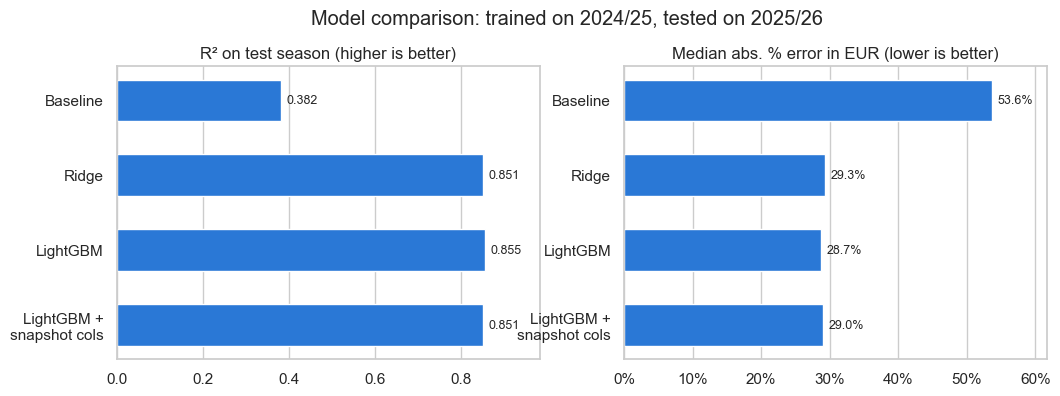

In [10]:
test_m = metrics[metrics["split"] == "test"].set_index("model").loc[list(preds)]
labels = ["Baseline", "Ridge", "LightGBM", "LightGBM +\nsnapshot cols"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, col, title, fmt in [
    (axes[0], "r2", "R² on test season (higher is better)", "{:.3f}"),
    (axes[1], "mdape_eur", "Median abs. % error in EUR (lower is better)", "{:.1%}"),
]:
    bars = ax.barh(labels, test_m[col], color=BASE_COLOR, height=0.55)
    ax.bar_label(bars, labels=[fmt.format(v) for v in test_m[col]], padding=4, fontsize=9)
    ax.invert_yaxis()
    ax.set(title=title)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.15)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.suptitle(f"Model comparison: trained on {config.season_label(config.TRAIN_SEASON)}, "
             f"tested on {config.season_label(config.TEST_SEASON)}", y=1.03)
save(fig, "06_model_comparison")
plt.show()

### Predicted vs actual (LightGBM, test season)
Points on the diagonal are predicted exactly. Points **above** the line have a higher market value than the model
explains (positive value gap), points **below** a lower one. Both axes are logarithmic.

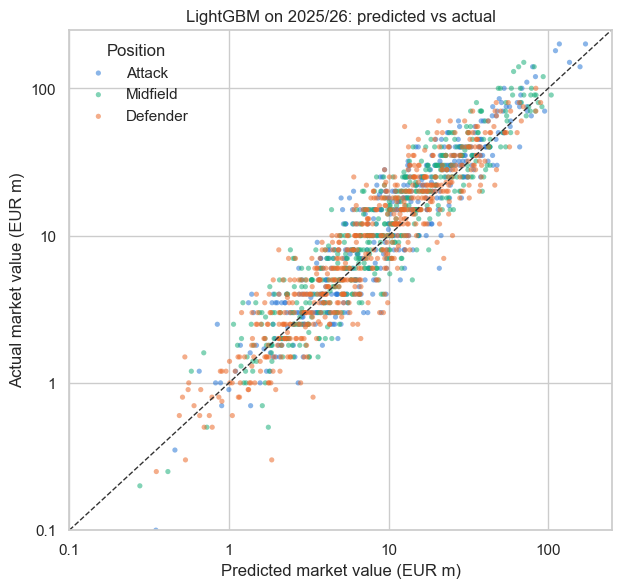

In [11]:
fig, ax = plt.subplots(figsize=(7, 6.5))
actual_m = np.exp(y_test) / 1e6
pred_m = np.exp(preds["lightgbm"]) / 1e6
for pos, color in POSITION_COLORS.items():
    mask = test["position"] == pos
    ax.scatter(pred_m[mask], actual_m[mask], s=14, alpha=0.55, color=color, label=pos, edgecolors="none")
lims = [0.1, 250]
ax.plot(lims, lims, color="#333333", linewidth=1, linestyle="--")
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
       xlabel="Predicted market value (EUR m)", ylabel="Actual market value (EUR m)",
       title=f"LightGBM on {config.season_label(config.TEST_SEASON)}: predicted vs actual")
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}"))
ax.legend(title="Position", frameon=False)
save(fig, "07_predicted_vs_actual")
plt.show()

### Which features does LightGBM use most? (first look)
Gain importance = how much each feature reduced the error across all tree splits. It shows *what* the model relies
on, not the direction of the effect. Gain is a quick first look but tends to favour features with many possible
split points (here: team goal difference). Notebook 03 adds the direction with SHAP, and notebook 04 compares four
importance methods and groups correlated features, which gives the most reliable ranking.

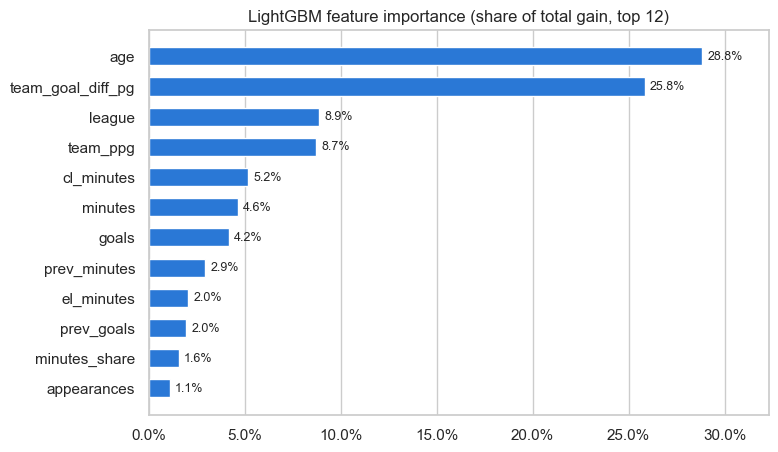

In [12]:
imp = pd.Series(lgbm.booster_.feature_importance("gain"), index=lgbm.booster_.feature_name())
imp = (imp / imp.sum()).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp.index, imp.values, color=BASE_COLOR, height=0.6)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in imp.values], padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
ax.set(title="LightGBM feature importance (share of total gain, top 12)")
save(fig, "08_feature_importance")
plt.show()

## 7. Findings
*Numbers from the run on 2026-09-30; reproduced by `python -m src.train_models`.*

- **Both real models beat the baseline by far:** test R² 0.851 (Ridge) and 0.855 (LightGBM) vs 0.382; MdAPE 29% vs 54%.
- **The model generalises (research question 3):** test scores on 2025/26 are as good as cross-validation on 2024/25.
- **Ridge is almost as good as LightGBM.** The simple, interpretable model costs little accuracy.
- **Snapshot columns confirm the leakage decision:** they improve train CV R² (0.881 to 0.886) but make the test
  score slightly worse (0.855 to 0.851). They look useful in-sample and do not generalise.
- **Top drivers (gain, first look):** age and team strength (goal difference, points per game) dominate, followed
  by league and Champions League minutes. Part of what the model learns is "players at top clubs are worth more".
  The robust ranking by concept follows in notebook 04 (age 40%, team strength 17-22%, league 16-17%).

**Next:** notebook 03 explains direction and size of the effects with SHAP and computes the value gap.

In [13]:
# Uncomment to also write predictions, metrics and models (same as `python -m src.train_models`)
# from src.train_models import main; main()